In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp as sivp
from numpy import sin, cos, exp, sqrt, mod, heaviside

In [2]:
# PARAMETERS (from hpa_fmd_diab.py)
pars={} 

inf = np.inf

pars['w1']=244.8
pars['w2']=50.4
pars['w3']=12.384
pars['kgr']=4
pars['n']=3
pars['whpa']=0.02083
pars['lam']=1
pars['wcrhe']=23.04
pars['wc']=0.02
pars['wa']=0.01
pars['wr']=0.023
pars['wcr']=0
pars['ub']=1
pars['uon']=0
pars['uoff']=3600
pars['uinp']=1
pars['don']=0
pars['doff']=0
pars['dinp']=20
pars['per']=30
pars['slt']=20
pars['sw']=1

pars['eg0']=24.48
pars['k']=700
pars['bv']=5
pars['mmax']=1
pars['alpha_m']=140
pars['km']=2
pars['alpha_isr']=1.2
pars['kisr']=2
pars['pmax']=4.55
pars['kp']=4
pars['alpha_p']=35
pars['p_b']=0
pars['amax']=5
pars['alpha_a']=0.37
pars['ka']=6
pars['a_b']=0.9
pars['tau_b']=1800
pars['height']=1.66
pars['age_b']=64
pars['sex']=1
pars['cage']=0
pars['target_si']=1.8
pars['tau_si']=1
pars['bmi_h']=22
pars['mffa']=0.8

pars['ksi_infl']=4.0
pars['ksi_ffa']=400
pars['nsi_ffa']=6
pars['sw11']=1
pars['inc_i1']=0
pars['inc_i2']=0
pars['inc_i3']=0
pars['it1']=0
pars['it2']=inf
pars['it3']=inf
pars['kpc']=7700
pars['tau_w']=1

pars['k_infl']=6.0
pars['n_infl']=2
pars['infl_b']=0
pars['tau_infl']=1
pars['hgp_bas']=2000

pars['hepa_max']=3000
pars['hepa_sic']=1
pars['a_hgp']=4
pars['gcg']=0.1
pars['k_gcg']=0
pars['s']=0.0002

pars['png']=350
pars['sigma_b']=600

pars['sgmu']=1.5
pars['sgmd']=1
pars['sfm']=1.2
pars['sim']=0.25
pars['sgku']=81
pars['sgkd']=137
pars['sfk']=357
pars['sik']=0.6
pars['nsgku']=6
pars['nsgkd']=6
pars['nsfk']=6
pars['nsik']=4
pars['tau_sigma']=1
pars['sci']=1 
pars['gclamp']=0
pars['iclamp']=0
pars['maxinfl']=1
pars['l0']=170
pars['l2']=8.1
pars['cf']=2
pars['ksif']=11
pars['aa']=2
pars['sif']=1
pars['ffa_ramax']=1.12

pars['max_w']=0.5
pars['kcort']=1
pars['ncort']=2
pars['kcortsi'] = 1.0 

pars['k_fmass']=1.2
pars['n_fmass']=2
pars['max_cort']=0.5

pars['p_vf_base'] = 0.2     
pars['p_vf_amp'] = 0.2 
pars['k_p'] = 1
pars['n_p'] = 2

pars['maxinfl_vf']=0.9  
pars['maxinfl_sf']=0.1  

pars['max_insulin']=0.1
pars['k_i']=15
pars['n_i']=2

pars['intake_i']=2380

pars['kcrd'] = 61.9
pars['khgp'] = 16.1
pars['chgp'] = 0.027
pars['racor'] = 0.54 
pars['racor1'] = 0.075
pars['maxrd'] = 215  

pars['nhgp'] = 2
pars['ncrd'] = 2
pars['ncsi'] = 2 
pars['tata'] = 2

# Convert to array for the solver
p_base = np.array(list(pars.values()))

In [3]:
# ODE SYSTEM (from hpa_fmd_diab.py)
def odde(t,y,pars_npa): 

	heav=lambda x: np.heaviside(x,1) 

 #Initial Values 
	crh=y[0]
	acth=y[1]
	cort=y[2]
	cmass=y[3]
	amass=y[4]
	# res=y[5]
	cr=y[5]
	ext_crh=y[6]
	g=y[7]
	i=y[8]
	ffa=y[9]
	si=y[10]
	b=y[11]
	sigma=y[12]
	infl=y[13]
	w=y[14]
	fmass=y[15]
	vf=y[16]
	sf=y[17]  

 #Parameter Values 
	w1=pars_npa[0]
	w2=pars_npa[1]
	w3=pars_npa[2]
	kgr=pars_npa[3]
	n=pars_npa[4]
	whpa=pars_npa[5]
	lam=pars_npa[6]
	wcrhe=pars_npa[7]
	wc=pars_npa[8]
	wa=pars_npa[9]
	wr=pars_npa[10]
	wcr=pars_npa[11]
	ub=pars_npa[12]
	uon=pars_npa[13]
	uoff=pars_npa[14]
	uinp=pars_npa[15]

	don=pars_npa[16]
	doff=pars_npa[17]
	dinp=pars_npa[18]
	per=pars_npa[19]
	slt=pars_npa[20]
	sw=pars_npa[21]
	eg0=pars_npa[22]
	k=pars_npa[23]
	bv=pars_npa[24]
	mmax=pars_npa[25]
	alpha_m=pars_npa[26]
	km=pars_npa[27]
	alpha_isr=pars_npa[28]
	kisr=pars_npa[29]
	pmax=pars_npa[30]
	kp=pars_npa[31]
	alpha_p=pars_npa[32]
	p_b=pars_npa[33]
	amax=pars_npa[34]
	alpha_a=pars_npa[35]
	ka=pars_npa[36]
	a_b=pars_npa[37]
	tau_b=pars_npa[38]
	height=pars_npa[39]
	age_b=pars_npa[40]
	sex=pars_npa[41]
	cage=pars_npa[42]
	target_si=pars_npa[43]
	tau_si=pars_npa[44]
	bmi_h=pars_npa[45]
	mffa=pars_npa[46]
	ksi_infl=pars_npa[47]
	ksi_ffa=pars_npa[48]
	nsi_ffa=pars_npa[49]
	sw11=pars_npa[50]
	inc_i1=pars_npa[51]
	inc_i2=pars_npa[52]
	inc_i3=pars_npa[53]
	it1=pars_npa[54]
	it2=pars_npa[55]
	it3=pars_npa[56]
	kpc=pars_npa[57]
	tau_w=pars_npa[58]
	k_infl=pars_npa[59]
	n_infl=pars_npa[60]
	infl_b=pars_npa[61]
	tau_infl=pars_npa[62]
	hgp_bas=pars_npa[63]
	hepa_max=pars_npa[64]
	hepa_sic=pars_npa[65]
	a_hgp=pars_npa[66]
	gcg=pars_npa[67]
	k_gcg=pars_npa[68]
	s=pars_npa[69]
	png=pars_npa[70]
	sigma_b=pars_npa[71]
	sgmu=pars_npa[72]
	sgmd=pars_npa[73]
	sfm=pars_npa[74]
	sim=pars_npa[75]
	sgku=pars_npa[76]
	sgkd=pars_npa[77]
	sfk=pars_npa[78]
	sik=pars_npa[79]
	nsgku=pars_npa[80]
	nsgkd=pars_npa[81]
	nsfk=pars_npa[82]
	nsik=pars_npa[83]
	tau_sigma=pars_npa[84]
	sci=pars_npa[85]
	gclamp=pars_npa[86]
	iclamp=pars_npa[87]
	maxinfl=pars_npa[88]
	l0=pars_npa[89]
	l2=pars_npa[90]
	cf=pars_npa[91]
	ksif=pars_npa[92]
	aa=pars_npa[93]
	sif=pars_npa[94]
	ffa_ramax=pars_npa[95]

	max_w=pars_npa[96]
	kcort=pars_npa[97]
	ncort=pars_npa[98]

	kcortsi=pars_npa[99]

	k_fmass=pars_npa[100]
	n_fmass=pars_npa[101]
	max_cort=pars_npa[102]

	p_vf_base=pars_npa[103]  
	p_vf_amp=pars_npa[104]
	k_p=pars_npa[105]
	n_p=pars_npa[106]

	# alpha=pars_npa[107]
	maxinfl_vf=pars_npa[107]
	maxinfl_sf=pars_npa[108]

	max_insulin=pars_npa[109]
	k_i=pars_npa[110]
	n_i=pars_npa[111]
	intake_i=pars_npa[112]

	kcrd = pars_npa[113]
	khgp = pars_npa[114]
	chgp = pars_npa[115]
	racor = pars_npa[116]
	racor1 = pars_npa[117]
	maxrd = pars_npa[118]
	nhgp = pars_npa[119]
	ncrd = pars_npa[120]
	ncsi = pars_npa[121] 
	tata = pars_npa[122]
	
#Numerics 

	u1 = ub+(heav(t-uon)-heav(t-uoff))*uinp
	d = 0+(heav(t-don)-heav(t-doff))*dinp
	uw = ub+uinp*heav(mod(t,per)-slt)
	u = sw*u1+(1-sw)*uw
	

	stim_crh =  crh+ext_crh
	# gcort = 1/(1+((cort*res)/kgr)**n)
	gcort = 1/(1+(cort/kgr)**n)
	mcort = 1/cort
	bmi = w/height**2
	age = age_b+cage*t/365

	#tsi = 1.8*target_si*(ksi_infl/(ksi_infl+infl))*(1-mffa*ffa**nsi_ffa/(ffa**nsi_ffa+ksi_ffa**nsi_ffa))*1/(1+(kcortsi*cort))
	#tsi = tata*target_si*(ksi_infl/(ksi_infl+infl))*(1-mffa*ffa**nsi_ffa/(ffa**nsi_ffa+ksi_ffa**nsi_ffa))*1/(1+(cort/kcortsi))
	tsi = (kcortsi**ncsi/(kcortsi**ncsi+(cort-1)**ncsi))*target_si*(ksi_infl/(ksi_infl+infl))*(1-mffa*ffa**nsi_ffa/(ffa**nsi_ffa+ksi_ffa**nsi_ffa))


	inc_int =  0 + heav(t-it1)*heav(it2-t)*heav(it3-t)*inc_i1 + heav(t-it2)*heav(it3-t)*inc_i2 + heav(t-it3)*inc_i3
	w_base = 77
	
	activity_level = 1.6
	bmr = sex * (
		(age < 30) * (15.057 * w + 692.2) + 
		((age >= 30) & (age < 60)) * (11.472 * w + 873.1) + 
		(age >= 60) * (11.711 * w + 587.7)
	) + (1 - sex) * (
		(age < 30) * (14.818 * w + 486.6) + 
		((age >= 30) & (age < 60)) * (8.126 * w + 845.6) + 
		(age >= 60) * (9.082 * w + 658.5)
	)
	expd = activity_level * bmr

	k_w = 1/kpc
	m = mmax*g**km/(alpha_m**km + g**km)
	isr =  sigma*(m)**kisr/(alpha_isr**kisr + (m)**kisr)
	p_isr = p_b + pmax*isr**kp/(alpha_p**kp + isr**kp)
	a_m = a_b + amax*m**ka/(alpha_a**ka + m**ka)
	p =  p_isr
	a =  a_m

	fmr =  sex*(-0.12 + 0.013*bmi) + (1-sex)*(0.07 + 0.01*bmi)
	ffm = w-fmass

	inc = 1+inc_int
	hepa_si = hepa_sic*si
	#hgp = (hgp_bas + hepa_max*(a_hgp+k_gcg*gcg*(bmi-25)/25)/((a_hgp+k_gcg*gcg*(bmi-25)/25)+hepa_si*i))
	#hgp = hgp_bas + hepa_max*((1+chgp*(cort-1))*khgp/((1+chgp*(cort-1))*khgp+(hepa_si*i)**nnn))
	hgp = hgp_bas + (1+chgp*(cort-1))*hepa_max*khgp**nhgp/(khgp**nhgp+(hepa_si*i)**nhgp)
	
	intake = intake_i*inc
	s_glucu = sgmu*g**nsgku/(g**nsgku+sgku**nsgku)
	s_glucd = sgmd*g**nsgkd/(g**nsgkd+sgkd**nsgkd)
	s_ffa = sfm*ffa**nsfk/(ffa**nsfk+sfk**nsfk)
	s_infl = sim*infl**nsik/(infl**nsik+sik**nsik)
	s_inf = sigma_b*(s_glucu - s_glucd*s_ffa - s_infl)
	siff = si*sif
	cl0 = l0*24*60/bv
	cl2 = l2*24*60/bv
	al0 = 2.45*24*60


	# vrr  = rho *(alpha + cort**ncort/(cort**ncort+kcort**ncort))

	p_vf_base = sex * 0.25 + (1 - sex) * 0.15

	p_vf = p_vf_base + p_vf_amp * (cort-1)**n_p / ((cort-1)**n_p + k_p**n_p)
	p_sf = 1.0 - p_vf

	#rd=(eg0+sci*(si*i)+(1-racor*(cort-1))*mmrd*(si*i)**nnrd/(kkk**nnrd+(si*i)**nnrd))*g
	rd=(eg0+sci*(si*i)+(1-racor1*(cort-1))*maxrd*(si*i)**ncrd/((1-racor*(cort-1))*kcrd**ncrd+(si*i)**ncrd))*g

#Diferetial Equations 
	# The following equations are adaped/taken from HPA model in to describe cortisol dynamics (DOI: https://doi.org/10.15252/msb.20209510)
	# Both mdoels interact at certain points
	dcrh=w1*(gcort*mcort*u-crh)
	dacth=w2*(cmass*gcort*stim_crh-acth)
	dcort=w3*(amass*acth-cort/cr)
	dcmass=wc*cmass*(stim_crh-1)
	damass=wa*amass*(acth-1)
	# dres=wr*(1-(1+cort**2)*res)
	dcr=wcr*(cort-cr)
	dext_crh=wcrhe*(d-ext_crh)
	
	# Following Equations taken from the weight gain T2D development model (DOI: 10.1016/j.isci.2023.108324)
	#dg=gclamp+hgp-(eg0+sci*si*i)*g
	dg=gclamp+hgp-rd # The equation describes the glucose dynamics
	di=iclamp+b*isr/bv-k*i # The equation describes the insulin dynamics

	dffa=(cl0+cl2*fmass)*(ffa_ramax*(ksif**aa)/(ksif**aa+(siff*i)**aa))-cf*w*ffa # The equation describes the free fatty acid dynamics

	dsi=(tsi-si)/tau_si # The equation describes the insulin sensitivity dynamics
	db=(png+p*b-a*b-s*b**2)/tau_b # The equation describes the beta cell mass dynamics
	dsigma=(s_inf-sigma)/tau_sigma # The equation describes beta cell function dynamics

	# New equations for infl describes the inflammation dynamics
	vf_term = vf**n_infl/(vf**n_infl+k_infl**n_infl)
	sf_term = sf**n_infl/(sf**n_infl+k_infl**n_infl)
	infl_drive = maxinfl_vf*vf_term + maxinfl_sf*sf_term
	dinfl = infl_b + (infl_drive - infl)/tau_infl 
	

	i_thresh = 10.0  # normal fasting insulin
	i_eff = max(0, i - i_thresh)  
	phi_insulin = max_insulin * i_eff**n_i / (k_i**n_i + i_eff**n_i)

	cortisol_factor = 1 + max_w * (cort-1)**ncort / (kcort**ncort + (cort-1)**ncort)

	
	carb_frac = 0.5 
	phi = carb_frac * intake * k_w * phi_insulin * cortisol_factor
	dw = (intake * k_w - expd * k_w + phi) / tau_w # The equation for w describes the body weight dynamics
	
	p_fmass = 0.35
	dfmass = (p_fmass * (intake * k_w - expd * k_w) + phi)/tau_w

	dvf=p_vf*dfmass # The equation for visceral fat
	dsf=p_sf*dfmass # The equation for subcutaneous fat
	# Example: Don't let cortisol or glucose go below a tiny positive number
	
	cort = max(y[2], 0.001)
	g = max(y[7], 0.001)

	# dy=np.array([dcrh,dacth,dcort,dcmass,damass,dres,dcr,dext_crh,dg,di,dffa,dsi,db,dsigma,dinfl,dw,dfmass,dvf,dsf])
	dy=np.array([dcrh,dacth,dcort,dcmass,damass,dcr,dext_crh,dg,di,dffa,dsi,db,dsigma,dinfl,dw,dfmass,dvf,dsf])

	return dy

# Simulation

In [4]:
# helper function to run the sim for the sweep
def run_twin_sim(patient, current_pars):
    # initial conditions from your notebook
    y0 = [1, 1, 1, 1, 1, 1, 0, patient['G_mgdl'], 9, 400, 0.8, 900, 536, 0.73, 77, 18.7, 2.8, 15.9]
    p_sim = current_pars.copy()
    p_sim[15] = patient['S_input'] # stress input is index 15
    try:
        sol = sivp(odde, [0, 7200], y0, method='LSODA', args=[p_sim])
        return sol.y[7][-1] 
    except:
        return patient['G_mgdl']

In [5]:
# T2D STRESS TEST
df = pd.read_csv("t2d_pilot_50_diabetics.csv")
final_results = []

for idx, patient in df.iterrows():
    # Initial Conditions: Glucose set by UK Biobank data
    y0 = [1, 1, 1, 1, 1, 1, 0, patient['G_mgdl'], 9, 400, 0.8, 900, 536, 0.73, 77, 18.7, 2.8, 15.9]
    
    p_fail = p_base.copy()
    p_fail[15] = patient['S_input'] 
    
    try:
        sol = sivp(odde, [0, 7200], y0, method='LSODA', args=[p_fail])
        g_start, g_end = sol.y[7][0], sol.y[7][-1]
        
        # Loss of Resilience Check
        status = 'Crash' if g_end > (g_start + 5) else 'Stable'
        
        final_results.append({'eid': patient['eid'], 'Start': g_start, 'End': g_end, 'Delta': g_end - g_start, 'Status': status})
    except:
        continue

res_df = pd.DataFrame(final_results)
print(res_df['Status'].value_counts())

Status
Stable    50
Name: count, dtype: int64


In [6]:
# --- PART 3: HEALTHY COHORT (The Control) ---
df_h = pd.read_csv("t2d_pilot_50_healthy.csv")
healthy_results = []

for idx, patient in df_h.iterrows():
    y0 = [1, 1, 1, 1, 1, 1, 0, patient['G_mgdl'], 9, 400, 0.8, 900, 536, 0.73, 77, 18.7, 2.8, 15.9]
    p_fail = p_base.copy()
    p_fail[15] = patient['S_input']
    
    try:
        sol = sivp(odde, [0, 7200], y0, method='LSODA', args=[p_fail])
        g_start, g_end = sol.y[7][0], sol.y[7][-1]
        status = 'Crash' if g_end > (g_start + 5) else 'Stable'
        healthy_results.append({'eid': patient['eid'], 'Start': g_start, 'End': g_end, 'Delta': g_end - g_start, 'Status': status})
    except:
        continue

res_df_healthy = pd.DataFrame(healthy_results)
print(f"Healthy Verdict: {res_df_healthy['Status'].value_counts().get('Crash', 0)} Crashes out of {len(res_df_healthy)}")

Healthy Verdict: 21 Crashes out of 50


# Graphs

In [ ]:
# get the combined actual and simulated data for the plots
ukb_all = np.concatenate([df['G_mgdl'], df_h['G_mgdl']])
sim_all = np.concatenate([res_df['End'], res_df_healthy['End']])

# define the clinical thresholds for the bars and histograms
bins = [0, 100, 126, 1000] 
labels = ['Normal', 'IFG', 'Diabetes']

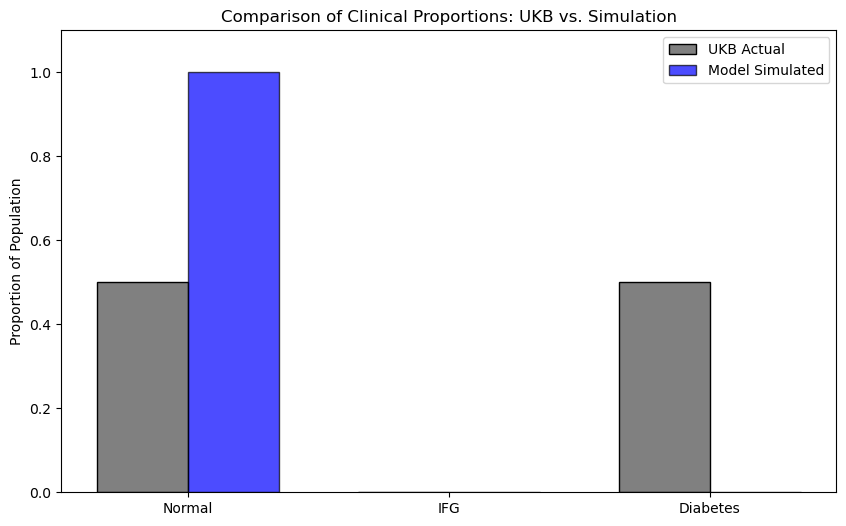

In [9]:
# define clinical thresholds 
bins = [0, 100, 126, 1000] 
labels = ['Normal', 'IFG', 'Diabetes']

# get counts for actual vs simulated
ukb_counts = pd.Series(pd.cut(ukb_all, bins=bins, labels=labels)).value_counts(normalize=True).reindex(labels)
sim_counts = pd.Series(pd.cut(sim_all, bins=bins, labels=labels)).value_counts(normalize=True).reindex(labels)

# set up the side-by-side bars
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, ukb_counts, width, label='UKB Actual', color='gray', edgecolor='black')
rects2 = ax.bar(x + width/2, sim_counts, width, label='Model Simulated', color='blue', edgecolor='black', alpha=0.7)

# add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Proportion of Population')
ax.set_title('Comparison of Clinical Proportions: UKB vs. Simulation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.ylim(0, 1.1)
plt.show()

/var/folders/r5/_05_w2k14p728pkkf57ysjg40000gn/T/ipykernel_14504/3505441967.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Source', y='Glucose', data=plot_data, inner='quartile', palette=['gray', 'blue'])


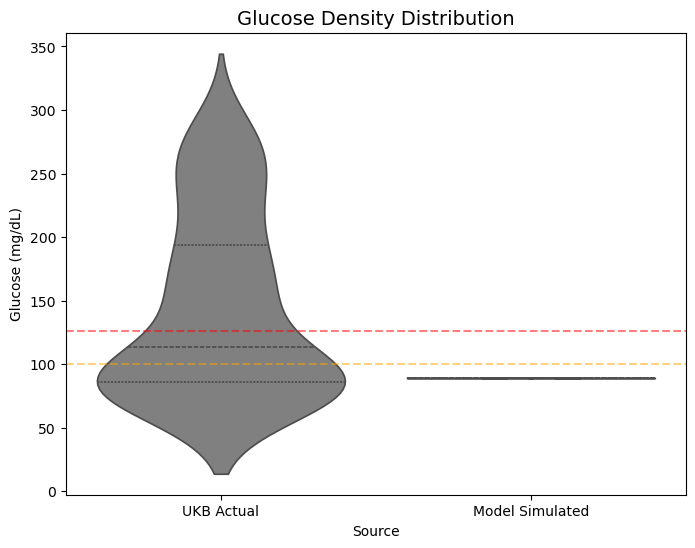

In [ ]:
# combine everything into one plotting df
plot_data = pd.DataFrame({
    'Glucose': np.concatenate([ukb_all, sim_all]),
    'Source': ['UKB Actual']*len(ukb_all) + ['Model Simulated']*len(sim_all)
})

plt.figure(figsize=(8, 6))

# violin plot with quartiles and custom colors
sns.violinplot(x='Source', y='Glucose', data=plot_data, inner='quartile', palette=['gray', 'blue'])

# add clinical lines
plt.axhline(y=126, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=100, color='orange', linestyle='--', alpha=0.5)

plt.title('Glucose Density Distribution', fontsize=14)
plt.ylabel('Glucose (mg/dL)')
plt.show()

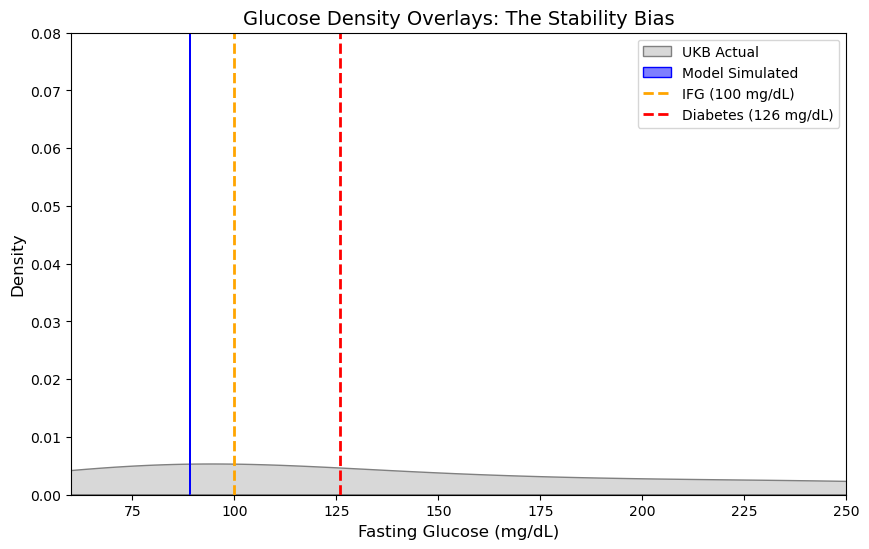

In [ ]:
plt.figure(figsize=(10, 6))

# calculate the hills with shading (adjusts the hill if it looks jagged)
sns.kdeplot(ukb_all, fill=True, color="gray", label='UKB Actual', alpha=0.3, bw_adjust=1.5)
sns.kdeplot(sim_all, fill=True, color="blue", label='Model Simulated', alpha=0.5, bw_adjust=0.5)

# add the clinical lines 
plt.axvline(x=100, color='orange', linestyle='--', label='IFG (100 mg/dL)', linewidth=2)
plt.axvline(x=126, color='red', linestyle='--', label='Diabetes (126 mg/dL)', linewidth=2)

# fix the axes so the blue spike doesn't squash the ukb hill
plt.ylim(0, 0.08) # SPIKE TALLNESS ADJUSTMENT
plt.xlim(60, 250) 

plt.xlabel('Fasting Glucose (mg/dL)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Glucose Density Overlays: The Stability Bias', fontsize=14)
plt.legend()
plt.show()

starting sweep...
k=0.10 -> 100.0% Diabetic
k=0.37 -> 74.0% Diabetic
k=0.63 -> 0.0% Diabetic
k=0.90 -> 0.0% Diabetic
k=1.17 -> 0.0% Diabetic
k=1.43 -> 0.0% Diabetic
k=1.70 -> 0.0% Diabetic
k=1.97 -> 0.0% Diabetic
k=2.23 -> 0.0% Diabetic
k=2.50 -> 0.0% Diabetic


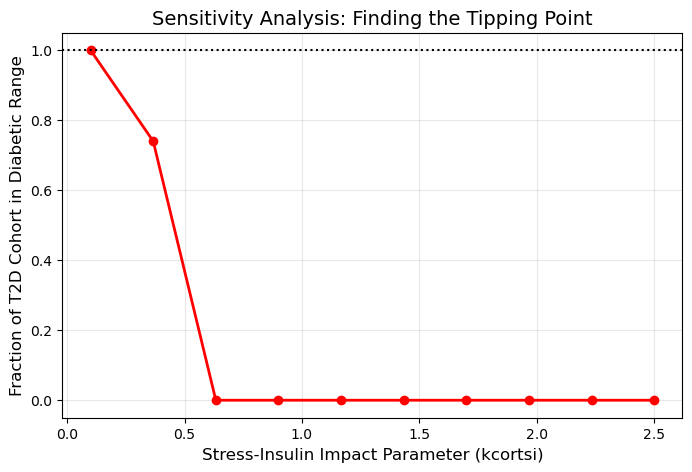

In [ ]:
# values of kcortsi to test
kcortsi_range = np.linspace(0.1, 2.5, 10)
diabetes_proportions = []
kc_idx = list(pars.keys()).index('kcortsi')

print("starting sweep...")

for k in kcortsi_range:
    p_sweep = p_base.copy()
    p_sweep[kc_idx] = k 
    
    sweep_results = []
    for i, twin in df.iterrows():
        g_end = run_twin_sim(twin, p_sweep)
        sweep_results.append(g_end)
    
    # calculate fraction that stayed in diabetic range (>126)
    diab_count = sum(1 for g in sweep_results if g >= 126)
    diabetes_proportions.append(diab_count / 50.0)
    print(f"k={k:.2f} -> {diab_count/50.0*100:.1f}% Diabetic")

# plotting the sensitivity
plt.figure(figsize=(8, 5))
plt.plot(kcortsi_range, diabetes_proportions, marker='o', linewidth=2, color='red')
plt.axhline(y=1.0, color='black', linestyle=':', label='Target (100% Match)')

plt.xlabel('Stress-Insulin Impact Parameter (kcortsi)', fontsize=12)
plt.ylabel('Fraction of T2D Cohort in Diabetic Range', fontsize=12)
plt.title('Sensitivity Analysis: Finding the Tipping Point', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

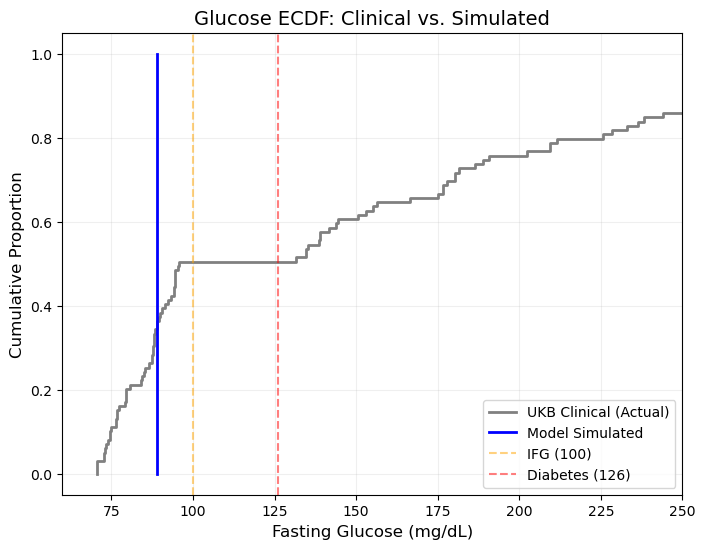

In [ ]:
# get the combined actual and simulated data
ukb_all = np.sort(np.concatenate([df['G_mgdl'], df_h['G_mgdl']]))
sim_all = np.sort(np.concatenate([res_df['End'], res_df_healthy['End']]))

# calculate the y-axis (proportions from 0 to 1)
y_ukb = np.linspace(0, 1, len(ukb_all))
y_sim = np.linspace(0, 1, len(sim_all))

plt.figure(figsize=(8, 6))

# plot the S-curves
plt.step(ukb_all, y_ukb, label='UKB Clinical (Actual)', color='gray', linewidth=2)
plt.step(sim_all, y_sim, label='Model Simulated', color='blue', linewidth=2)

# add the clinical cut points
plt.axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='IFG (100)')
plt.axvline(x=126, color='red', linestyle='--', alpha=0.5, label='Diabetes (126)')

plt.xlabel('Fasting Glucose (mg/dL)', fontsize=12)
plt.ylabel('Cumulative Proportion', fontsize=12)
plt.title('Glucose ECDF: Clinical vs. Simulated', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.xlim(60, 250)
plt.show()

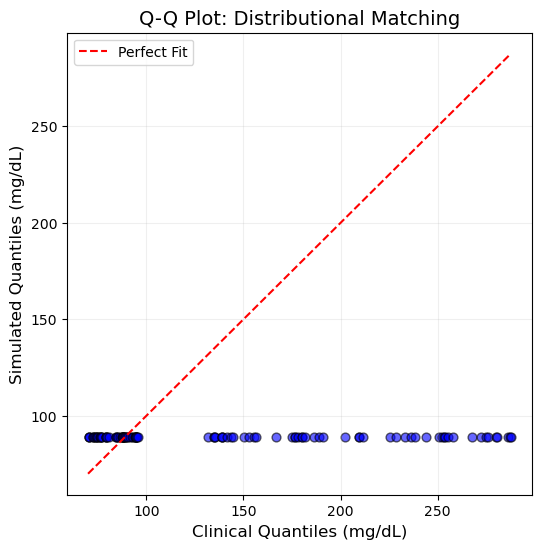

In [ ]:
# calculate quantiles (percentiles) for both sets
percs = np.linspace(0, 100, 100)
q_ukb = np.percentile(ukb_all, percs)
q_sim = np.percentile(sim_all, percs)

plt.figure(figsize=(6, 6))

# plot the points
plt.scatter(q_ukb, q_sim, color='blue', alpha=0.6, s=40, edgecolors='k')

# reference line for perfect fit
max_val = max(max(q_ukb), max(q_sim))
plt.plot([70, max_val], [70, max_val], color='red', linestyle='--', label='Perfect Fit')

plt.xlabel('Clinical Quantiles (mg/dL)', fontsize=12)
plt.ylabel('Simulated Quantiles (mg/dL)', fontsize=12)
plt.title('Q-Q Plot: Distributional Matching', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

finished kc=0.50
finished kc=1.00
finished kc=1.50
finished kc=2.00
finished kc=2.50
finished kc=3.00
finished kc=3.50
finished kc=4.00
finished kc=4.50
finished kc=5.00


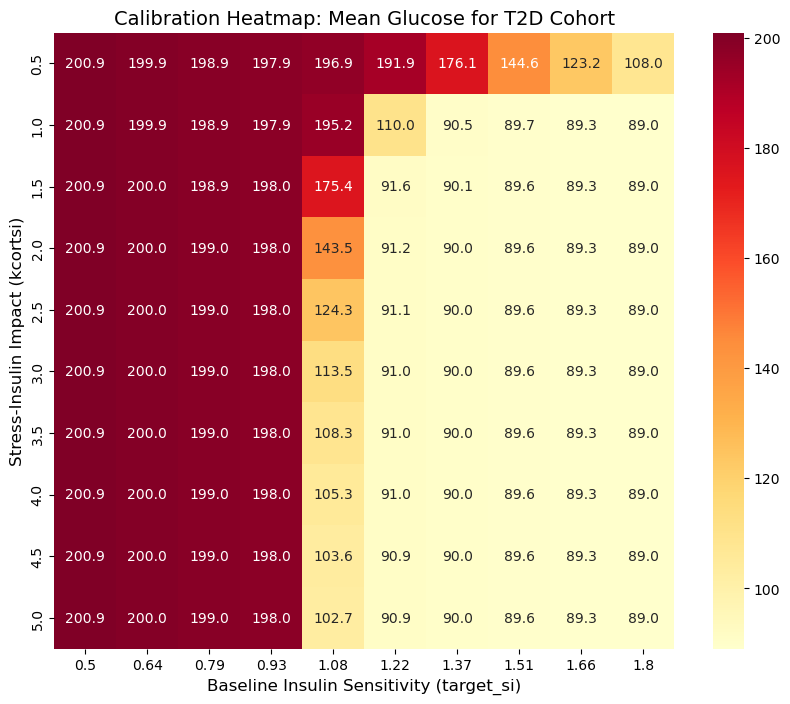

In [15]:
# ranges for the two-way sweep, kcortsi increases stress impact, target_si sets the baseline health
kc_range = np.linspace(0.5, 5.0, 10)
si_range = np.linspace(0.5, 1.8, 10)

# isolate the 50 diabetics for fast calibration
df_diab = df.copy() 

results_grid = []

for kc in kc_range:
    row_results = []
    for si_target in si_range:
        # copy base parameters and update the two knobs
        p_sweep = p_base.copy()
        p_sweep[99] = kc
        p_sweep[43] = si_target
        
        # run the 50 diabetics through this parameter combo
        combo_glucose = []
        for i, twin in df_diab.iterrows():
            g_end = run_twin_sim(twin, p_sweep)
            combo_glucose.append(g_end)
        
        # store the mean glucose for this specific (kc, si) coordinate
        mean_g = np.mean(combo_glucose)
        row_results.append(mean_g)
        
    results_grid.append(row_results)
    print(f"finished kc={kc:.2f}")

# convert to dataframe
sweep_df = pd.DataFrame(results_grid, index=np.round(kc_range, 2), columns=np.round(si_range, 2))

# plotting the calibration heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sweep_df, annot=True, fmt=".1f", cmap="YlOrRd")

plt.title('Calibration Heatmap: Mean Glucose for T2D Cohort', fontsize=14)
plt.xlabel('Baseline Insulin Sensitivity (target_si)', fontsize=12)
plt.ylabel('Stress-Insulin Impact (kcortsi)', fontsize=12)
plt.show()